In [146]:
import math

class Value:
    def __init__(self,data,_children=(),_op='',label=""):
        self.data = data
        self.grad = 0.0
        self._prev = _children
        self._op = _op
        self.label = label
        self._backward = lambda:None

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self,other),"+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out 
    
    def __radd__(self, other):
        return self + other
    
    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data,(self,other),"*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other

    def __repr__(self):
        return f"Value: {self.data}"
    
    def __iter__(self):
        for child in self._prev:
            yield child

    def __sub__(self, other):
        return self + (-other)

    def __neg__(self):
        return self * -1
    
    def __pow__(self, other):
        assert isinstance(other,(int,float)), "only supporting int/float powers for now "
        out = Value(self.data**other,(self,),f"**{other}")

        def _backward():
            self.grad = other * (self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t,(self,),"tanh")

        def _backward():
            self.grad = (1-t**2) * out.grad

        out._backward = _backward
        return out
    
        

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()



In [147]:
v1 = Value(2);v1.label = 'v1'
v2 = Value(3);v2.label = 'v2'
v3 = v1+v2;v3.label = 'v3'
b = Value(4) ;b.label = 'b'
v4 = v3+b ; v4.label = 'v4'
v5 = v4.tanh()
v5; v5.label = "v5"

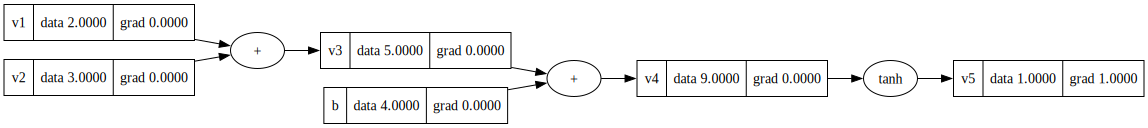

In [148]:
v5.backward()
draw_dots(v5)

In [149]:
from graphviz import Digraph

def trace(root):
    nodes,edges  = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            # print("\naddding this to node ",v)
            # print("Node",nodes)
            for child in v._prev:
                # print("\nadding these to edges",child,v)
                edges.add((child,v))
                # print("Edges",edges)
                build(child)
    build(root)
    return nodes,edges


def draw_dots(root):
    dot = Digraph(format='svg',graph_attr={'rankdir':'LR'}) #LR = left to right

    nodes,edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph,create a reactangular ('recored') node for it 
        dot.node(name=uid,label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad),shape = 'record')
        if n._op:
            # if this value is a result of some operation, create an op node for it 
            dot.node(name = uid + n._op,label = n._op)
            dot.edge(uid + n._op,uid)

    for n1,n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2)) + n2._op )
    return dot



In [150]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for i in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        # wx+b 

        act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b) 
        out = act.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]        
    

    def state_dict(self):
        return {
            "weights":self.w,
            "bias":[self.b]
        }

class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
    def state_dict(self):
        return {k:v for neuron in self.neurons for k,v in neuron.state_dict().items()}
    

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [l for layer in self.layers for l in layer.parameters()]
    
    def state_dict(self):
        return {k:v for layer in self.layers for k,v in layer.state_dict().items()}


In [151]:
x = [1.0,2.0]
n = MLP(3,[4,4,1])
n(x)

Value: 0.7753823972249062

In [152]:
len(n.parameters()) #,n.state_dict()

41

In [153]:
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_pred = [n(x) for x in xs]
y_pred

[Value: 0.7666845379397178,
 Value: 0.8525705767754499,
 Value: 0.7250517450191539,
 Value: 0.7751766750304452]

In [160]:
loss = sum((yp-ya)**2 for ya,yp in zip(ys,y_pred))
loss

Value: 6.317451805794548

In [178]:
loss.backward()
for p in n.parameters():
    p.data += -0.001 * p.grad

y_pred = [n(x) for x in xs]
loss = sum([(ygt - yout)**2  for ygt,yout in zip(y_pred,ys)])
loss


Value: 5.100822669329032

In [181]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yp-ya)**2 for ya,yp in zip(ys,ypred))

    #zero_grad()
    for p in n.parameters():
        p.grad = 0.0
    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k,loss.data)

0 5.100822669329032
1 3.664179717483702
2 3.5352893654560704
3 3.3971788021883884
4 3.2501044307802127
5 3.098910928251218
6 2.9494341535924304
7 2.8025570040876393
8 2.6505836166572223
9 2.4709438552948213
10 2.2104137848441847
11 1.7503657499936738
12 1.046865085878462
13 0.5567781953401671
14 0.3557520956225312
15 0.2557647767391172
16 0.1971362481661422
17 0.15905014469494427
18 0.13254275262634227
19 0.11314787760226801


In [191]:
y_preds = []
for pred in ypred:
    if pred.data>0.5:
        y_preds.append(1)        
    else:
        y_preds.append(-1)        
y_preds

[1, -1, -1, 1]

In [ ]:
y_preds.data 